<a href="https://colab.research.google.com/github/Ajinkya-18/Calorie-Burnt-Predictor/blob/main/Project2_Calorie_burnt_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor

In [2]:
calories_df = pd.read_csv('/content/calories.csv')
exercise_df = pd.read_csv('/content/exercise.csv')

In [3]:
calories_df.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [4]:
exercise_df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [5]:
df = pd.merge(exercise_df, calories_df, how='outer')

In [6]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [7]:
df.shape

(15000, 9)

In [8]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


##Exploratory Data Analysis

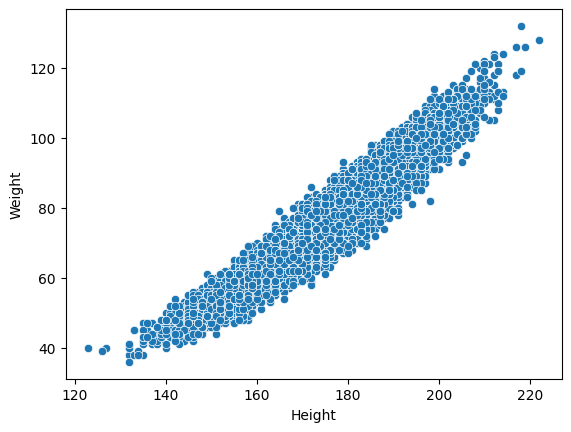

In [10]:
sb.scatterplot(x=df['Height'], y=df['Weight'])
plt.show()

<ipython-input-11-399998905990>:6: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(2,3,i+1)


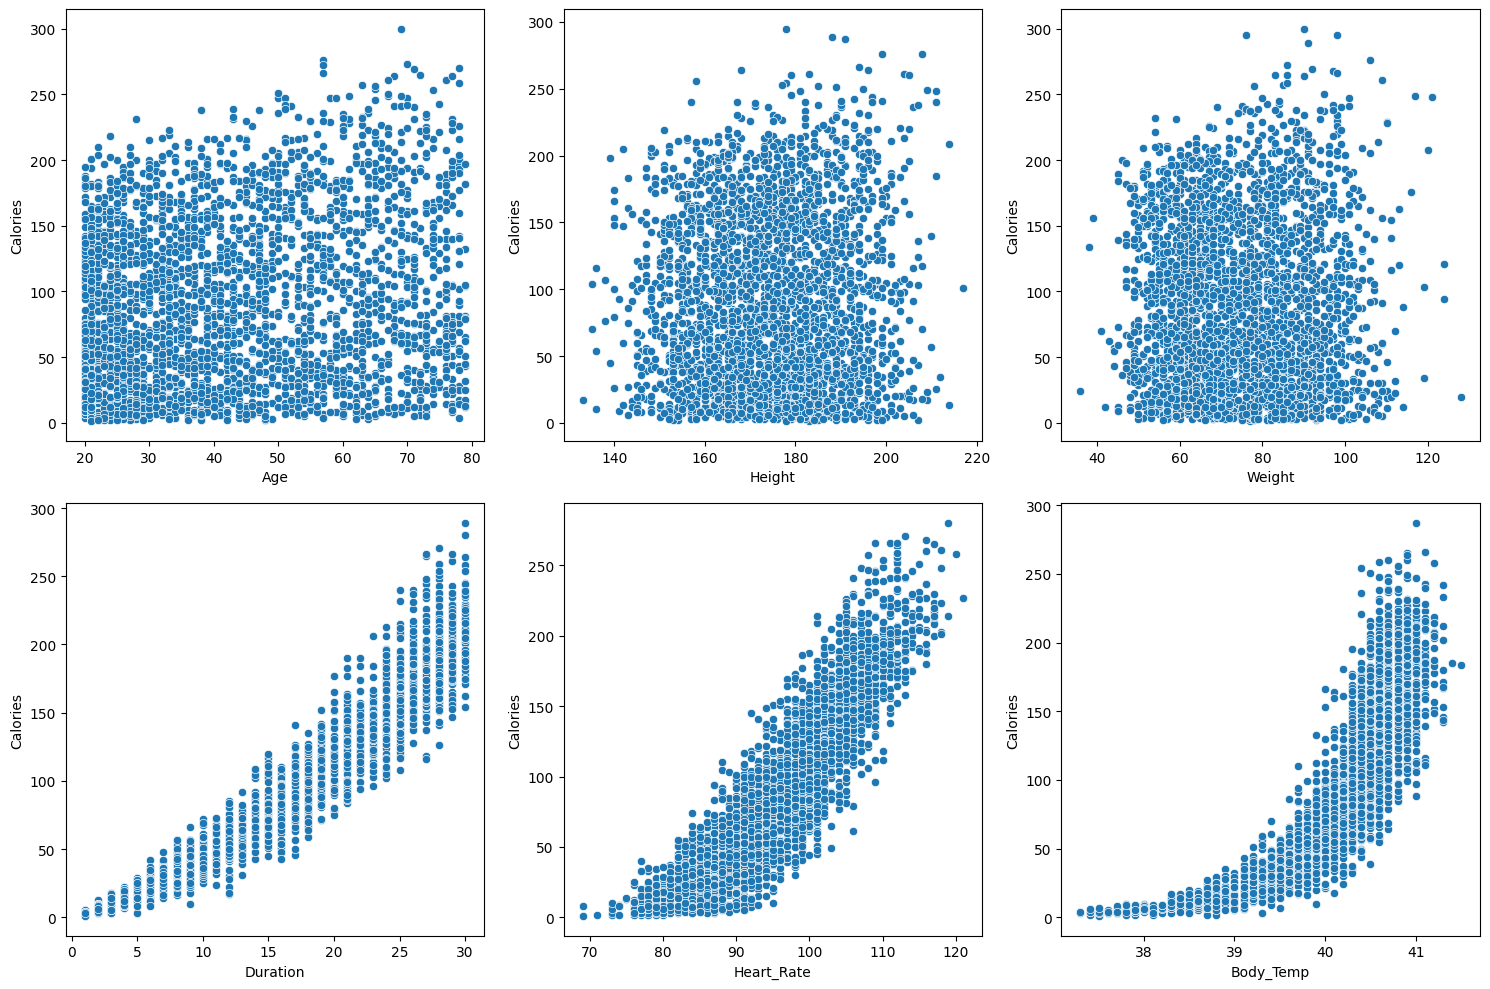

In [11]:
features = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']

plt.subplots(figsize=(15,10))

for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sample = df.sample(3000)
  sb.scatterplot(x=sample[col], y=sample['Calories'])

plt.tight_layout()
plt.show()

<ipython-input-12-361cc1036bc7>:6: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(2,3,i+1)


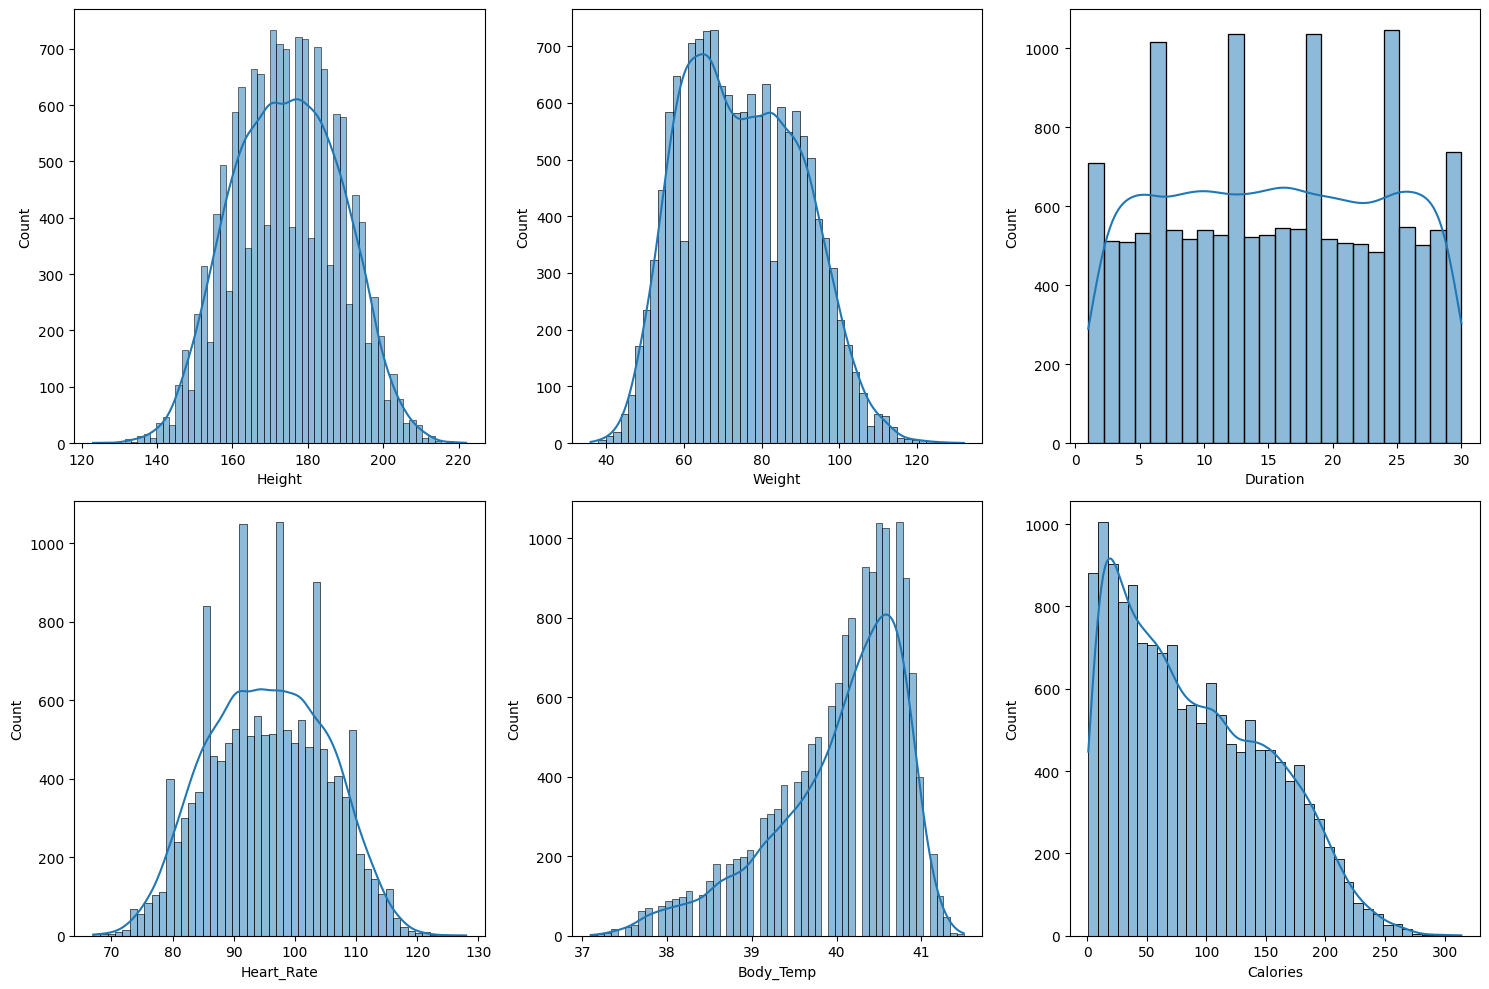

In [12]:
features1 = df.select_dtypes(include='float').columns

plt.subplots(figsize=(15,10))

for i, col in enumerate(features1):
  plt.subplot(2,3,i+1)
  sb.histplot(x = df[col], kde = True)

plt.tight_layout()
plt.show()

In [13]:
df.replace({'male':1, 'female':0}, inplace=True)
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,1,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,0,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,1,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,0,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,0,27,154.0,58.0,10.0,81.0,39.8,35.0


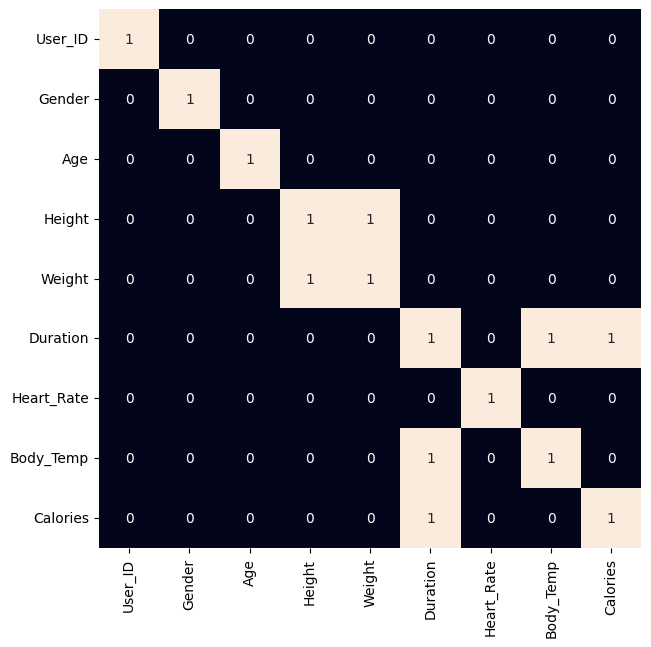

In [14]:
plt.figure(figsize=(7,7))
sb.heatmap(df.corr() > 0.9, annot=True, cbar=False)
plt.show()

In [15]:
df.drop('Duration', axis=1, inplace=True)

In [19]:
features = df[['Gender', 'Age', 'Height', 'Weight', 'Heart_Rate', 'Body_Temp']]
target = df['Calories']

x_train, x_test, y_train, y_test = train_test_split(features, target, test_size = 0.2, random_state = 42)

In [20]:
x_train.shape, x_test.shape

((12000, 6), (3000, 6))

In [21]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [22]:
from sklearn.metrics import mean_absolute_error as mae

In [24]:
models = [LinearRegression(), Lasso(), Ridge(), SVC(), XGBRegressor(), RandomForestRegressor()]
for i in range(0,6):
  models[i].fit(x_train, y_train)

  print(f'{models[i]}')
  train_pred = models[i].predict(x_train)
  test_pred = models[i].predict(x_test)

  print(f'training error: {mae(y_train, train_pred)}')
  print(f'testing error: {mae(y_test, test_pred)}')
  print()

LinearRegression()
training error: 17.861660574008237
testing error: 18.01873514416011

Lasso()
training error: 17.895748206637276
testing error: 18.07156194848015

Ridge()
training error: 17.861723290894034
testing error: 18.018847725064663

SVC()
training error: 13.037166666666666
testing error: 13.644333333333334

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=N